# Import Library

In [1]:
!pip install --upgrade nlp-id

In [2]:
import nlp_id
import os
print(os.listdir(os.path.dirname(nlp_id.__file__)))

['stopword.py', 'lemmatizer.py', 'data', 'tokenizer.py', 'postag.py', '__init__.py', '__pycache__']


In [3]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.util import ngrams
from wordcloud import WordCloud
import nltk
import re

from nlp_id.stopword import StopWord
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Load Data

In [4]:
df_maps = pd.read_excel('/content/google_maps_reviews_deep.xlsx')
df_ps = pd.read_excel('/content/klampid_playstore_reviews.xlsx')
df_ig = pd.read_excel('/content/instagram_comments_final.xlsx')

## Data Merging

In [5]:
df_maps['source'] = 'maps'
df_ps['source'] = 'ps'
df_ig['source'] = 'ig'

In [6]:
df = pd.concat([df_maps, df_ps, df_ig], ignore_index=True)
df = df[['source', 'comments', 'timestamp']]

# Basic Cleaning

In [ ]:
def basic_cleaning(text):
    if not isinstance(text, str):
        return ""
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = text.lower()
    text = re.sub(r'https?://\s+|www\.\s+', '', text) 
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)        
    text = re.sub(r'#[A-Za-z0-9_]+', '', text)        
    text = re.sub(r'[^\w\s]', ' ', text)              
    text = re.sub(r'\d+', '', text)                   
    text = re.sub(r'\s+', ' ', text).strip()          

    return text

In [8]:
df['text_clean'] = df['comments'].apply(basic_cleaning)

# EDA Phase 1

In [9]:
def get_top_ngram(corpus, n, top_n=20):
    words = [word for text in corpus for word in text.split()]
    if n == 1:
        return Counter(words).most_common(top_n)
    n_grams = ngrams(words, n)
    return Counter(n_grams).most_common(top_n)

## Word Frequency (Unigram)

In [10]:
top_unigram = get_top_ngram(df['text_clean'], 1)

In [11]:
print("Top Unigrams:", top_unigram)

Top Unigrams: [('di', 1067), ('dan', 934), ('saya', 732), ('ktp', 684), ('pelayanan', 612), ('bisa', 596), ('sangat', 422), ('mau', 421), ('tidak', 410), ('ada', 389), ('cepat', 372), ('yg', 369), ('ke', 357), ('surabaya', 353), ('sudah', 344), ('kk', 334), ('untuk', 325), ('min', 314), ('nya', 307), ('yang', 290)]


## N-Gram (2 dan 3)


In [12]:
top_bigram = get_top_ngram(df['text_clean'], 2)

In [13]:
print("Top Bigrams:", top_bigram)

Top Bigrams: [(('di', 'spp'), 116), (('cepat', 'dan'), 114), (('mau', 'tanya'), 88), (('terima', 'kasih'), 81), (('tidak', 'bisa'), 81), (('dan', 'cepat'), 74), (('ramah', 'dan'), 69), (('pelayanan', 'cepat'), 67), (('ktp', 'di'), 67), (('akta', 'kelahiran'), 67), (('e', 'ktp'), 65), (('spp', 'pakal'), 62), (('baik', 'dan'), 61), (('sangat', 'membantu'), 57), (('sangat', 'baik'), 56), (('saya', 'mau'), 55), (('apa', 'bisa'), 54), (('cetak', 'ulang'), 53), (('tidak', 'ada'), 52), (('cetak', 'ktp'), 52)]


In [14]:
top_trigram = get_top_ngram(df['text_clean'], 3)

In [15]:
print("Top Trigrams:", top_trigram)

Top Trigrams: [(('di', 'spp', 'pakal'), 50), (('ktp', 'di', 'spp'), 32), (('cetak', 'ulang', 'ktp'), 30), (('sangat', 'baik', 'dan'), 28), (('pelayanan', 'cepat', 'dan'), 28), (('layanan', 'lontong', 'balap'), 25), (('mudah', 'dan', 'cepat'), 24), (('di', 'spp', 'nambangan'), 23), (('di', 'spp', 'tij'), 19), (('spp', 'tij', 'joyoboyo'), 19), (('sangat', 'cepat', 'dan'), 18), (('cepat', 'dan', 'ramah'), 17), (('ulang', 'ktp', 'di'), 16), (('maaf', 'mau', 'tanya'), 16), (('pelayanan', 'sangat', 'baik'), 15), (('sangat', 'ramah', 'dan'), 14), (('sangat', 'mudah', 'dan'), 14), (('verifikasi', 'no', 'hp'), 14), (('mau', 'tanya', 'kalau'), 14), (('baik', 'dan', 'cepat'), 14)]


## Wordcloud

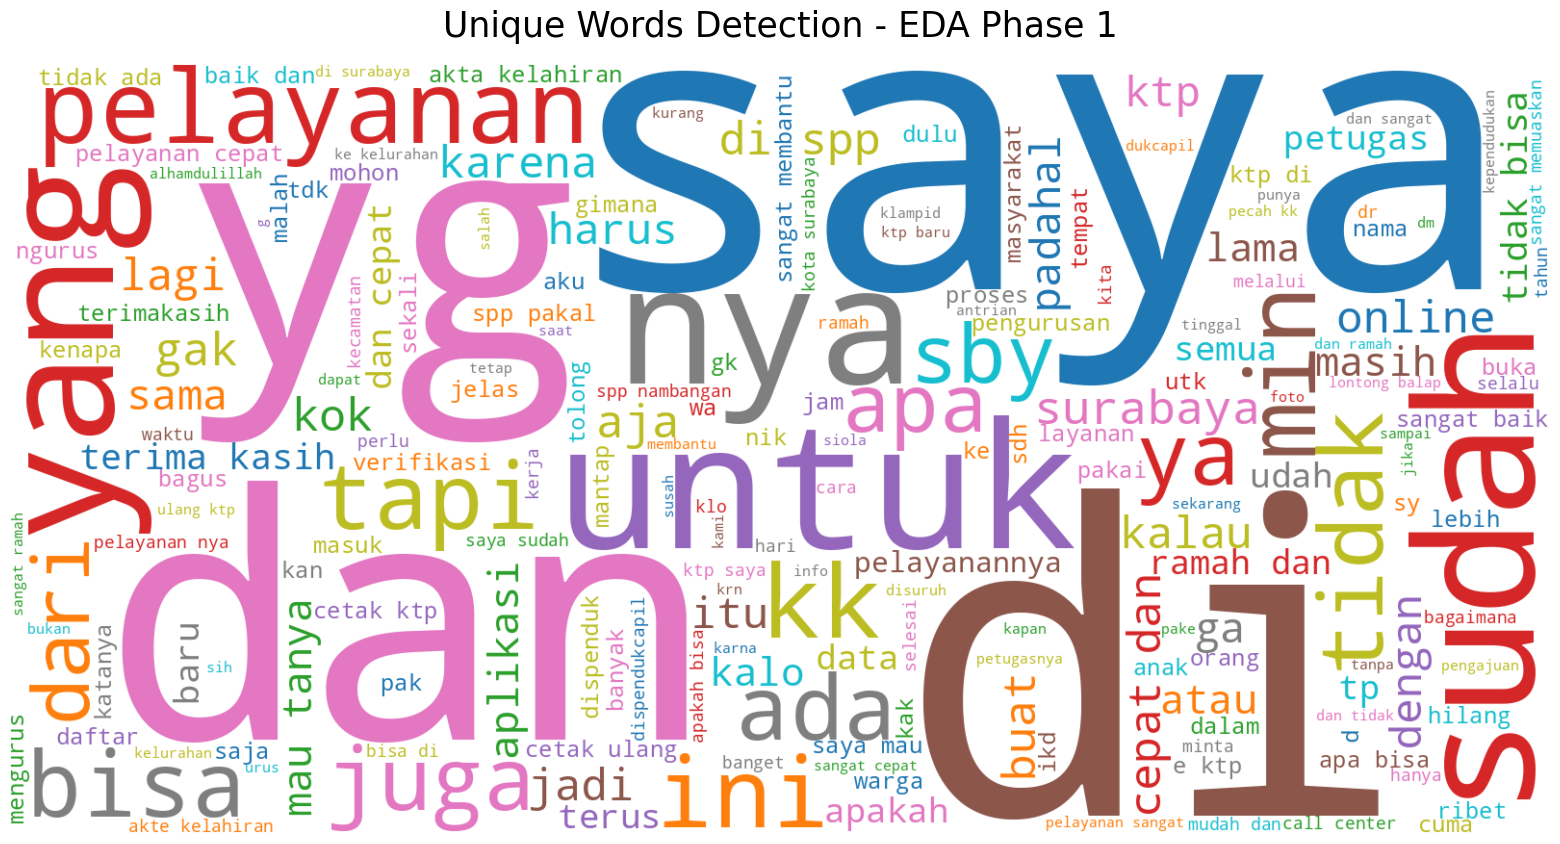

In [ ]:
def generate_unique_wordcloud(df_column, title):
    all_text = " ".join(df_column)
    wordcloud = WordCloud(
        width=1600,
        height=800,
        background_color='white',
        max_words=200,
        colormap='tab10',
        min_font_size=10,
        random_state=42
    ).generate(all_text)

    plt.figure(figsize=(20, 10))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=25, pad=20)
    plt.show()

generate_unique_wordcloud(df['text_clean'], "Unique Words Detection - EDA Phase 1")

In [17]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def generate_rare_wordcloud(df_column, min_freq=1, max_freq=2):
    all_words = " ".join(df_column).split()
    word_counts = Counter(all_words)
    rare_words = {word: count for word, count in word_counts.items()
                  if min_freq <= count <= max_freq and len(word) > 2}
    if not rare_words:
        print("Tidak ada kata yang memenuhi kriteria frekuensi tersebut.")
        return
    wordcloud = WordCloud(
        width=1600,
        height=800,
        background_color='black',
        colormap='spring',
        max_words=500,
        prefer_horizontal=1
    ).generate_from_frequencies(rare_words)

    plt.figure(figsize=(20, 10))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Rare Words Cloud (Freq: {min_freq}-{max_freq}x)", fontsize=25, pad=20)
    plt.show()


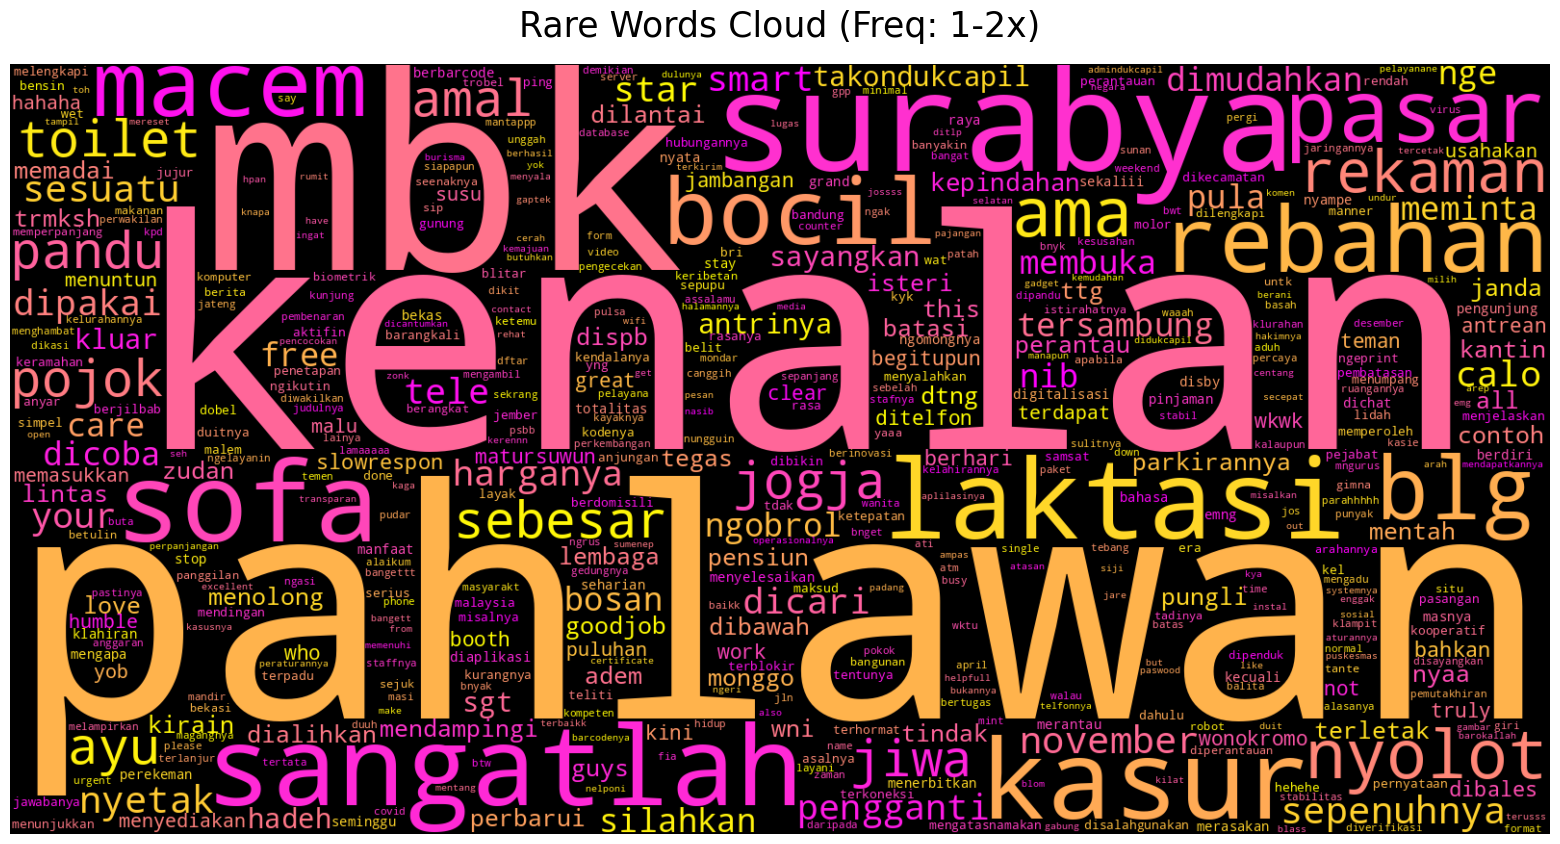

In [18]:
generate_rare_wordcloud(df['text_clean'])

# Refined Preprocessing

## Slang Mapping

In [ ]:
slang_dict = {
    "lontong balap": "lontong_balap",
    "cetak ulang": "cetak_ulang",
    "akta kelahiran": "akta_kelahiran",
    "nomor hp": "nomor_hp",
    "no hp": "nomor_hp",
    "kk": "kartu keluarga",
    "e ktp": "ktp",
    "ktp el": "ktp",

    "yg": "yang",
    "sdh": "sudah",
    "blm": "belum",
    "tgl": "tanggal",
    "wa": "whatsapp",
    "ngrus": "mengurus",
    "emng": "emang",
    "make": "memakai",
    "kpd": "kepada",
    "dr": "dari",
    "g": "tidak",
    "ga": "tidak",
    "gak": "tidak",
    "tdk": "tidak",
    "nggak": "tidak",
    "min": "admin",
    "sby": "surabaya",
    "klo": "kalau",
    "kl": "kalau",
    "utk": "untuk",
    "krn": "karena",
    "spp": "sentra_pelayanan",

    "mbk": "mbak",
    "trmksh": "terimakasih",
    "ttg": "tentang",
    "sgt": "sangat",
    "dtng": "datang",
    "blg": "bilang",
    "pake": "pakai",
    "kmarin": "kemarin"
}

## Stopword Handling

In [20]:
def handle_slang_and_phrases(text, slang_dict):
    if not isinstance(text, str):
        return ""

    sorted_phrases = sorted([k for k in slang_dict.keys() if ' ' in k], key=len, reverse=True)
    for phrase in sorted_phrases:
        text = text.replace(phrase, slang_dict[phrase])

    words = text.split()
    fixed_words = [slang_dict.get(w, w) for w in words]

    return " ".join(fixed_words)

In [21]:
df['text_refined'] = df['text_clean'].apply(lambda x: handle_slang_and_phrases(x, slang_dict))

print(df[['text_clean', 'text_refined']].head(10))

                                          text_clean  \
0  siola mall pelayanan publik dinas kependudukan...   
1  tempatnya bagus pelayanan cepat tapi sayang pe...   
2  disdukcapil surabaya inovasi digital demi warg...   
3  pelayanan adminduk di spp nambangan sangat bai...   
4  mengurus kk di pelayanan publik nambangan sang...   
5  pelayanan kependudukan di spp nambangan sangat...   
6  kehilangan ktp luar kota hilang dijln kalibutu...   
7  spp nambangan pelayanan dispenduk capil sangat...   
8  bagi surabaya utara yang mau ngurus adminduk b...   
9  pelayanan adminduk yang ada di sentra pelayana...   

                                        text_refined  
0  siola mall pelayanan publik dinas kependudukan...  
1  tempatnya bagus pelayanan cepat tapi sayang pe...  
2  disdukcapil surabaya inovasi digital demi warg...  
3  pelayanan adminduk di sentra_pelayanan nambang...  
4  mengurus kartu keluarga di pelayanan publik na...  
5  pelayanan kependudukan di sentra_pelayanan nam... 

## Handling Stopword

In [22]:
stopword_id = StopWord()
nlp_id_stoplist = stopword_id.get_stopword()
custom_stop = [
    'admin', 'min', 'halo', 'surabaya', 'siola', 'dispendukcapil',
    'terima', 'kasih', 'tolong', 'kak', 'bang', 'pak', 'bu', 'iya',
    'mohon', 'cek', 'tanya', 'salam', 'pagi', 'siang', 'sore', 'malam'
]

exclude_from_stop = ['tidak', 'belum', 'kurang', 'bukan']

final_stopwords_lda = [word for word in nlp_id_stoplist + custom_stop if word not in exclude_from_stop]

In [23]:
def remove_stopwords_nlp_id(text, is_for_neural=False):
    if not isinstance(text, str):
        return ""

    words = text.split()

    if is_for_neural:
        return " ".join([w for w in words if w not in custom_stop])
    else:
        return " ".join([w for w in words if w not in final_stopwords_lda])

In [24]:
df['text_for_lda'] = df['text_refined'].apply(lambda x: remove_stopwords_nlp_id(x, is_for_neural=False))
df['text_for_bertopic'] = df['text_refined'].apply(lambda x: remove_stopwords_nlp_id(x, is_for_neural=True))

# EDA Phase 2

In [ ]:
def plot_freq(df_column, title, color):
    words = [word for text in df_column for word in str(text).split()]
    top_words = Counter(words).most_common(30)
    labels, values = zip(*top_words)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(values), y=list(labels), palette=color)
    plt.title(title)
    plt.show()

def plot_wordcloud(df_column, title):
    all_text = " ".join(df_column.astype(str))
    wc = WordCloud(width=1600, height=800, background_color='white', colormap='viridis').generate(all_text)
    plt.figure(figsize=(15, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

def plot_dist(df, col_name, title, color):
    lengths = df[col_name].apply(lambda x: len(str(x).split()))
    plt.figure(figsize=(10, 5))
    sns.histplot(lengths, bins=30, kde=True, color=color)
    plt.title(title)
    plt.xlabel('Jumlah Kata')
    plt.show()

def plot_source(df, title):
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='source', palette='pastel')
    plt.title(title)
    plt.show()

## LDA

/tmp/ipykernel_18176/2564875411.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(values), y=list(labels), palette=color)


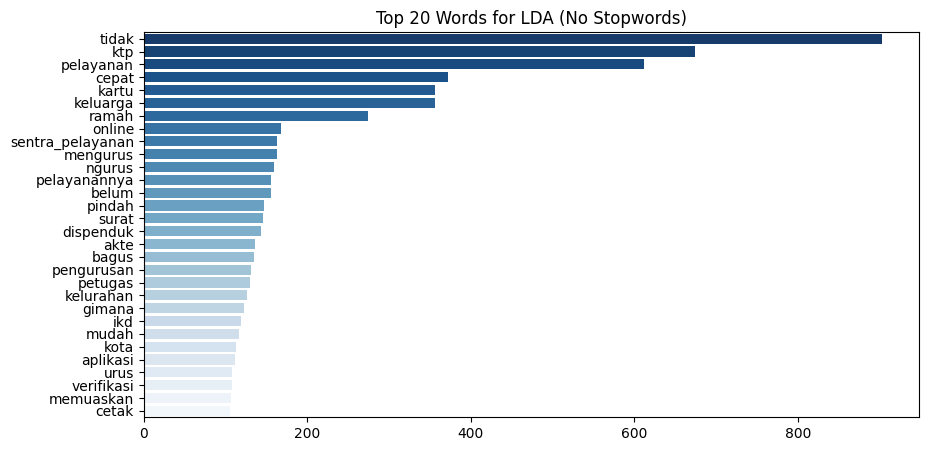

In [26]:
#@title Perbandingan Freq
plot_freq(df['text_for_lda'], "Top 20 Words for LDA (No Stopwords)", "Blues_r")

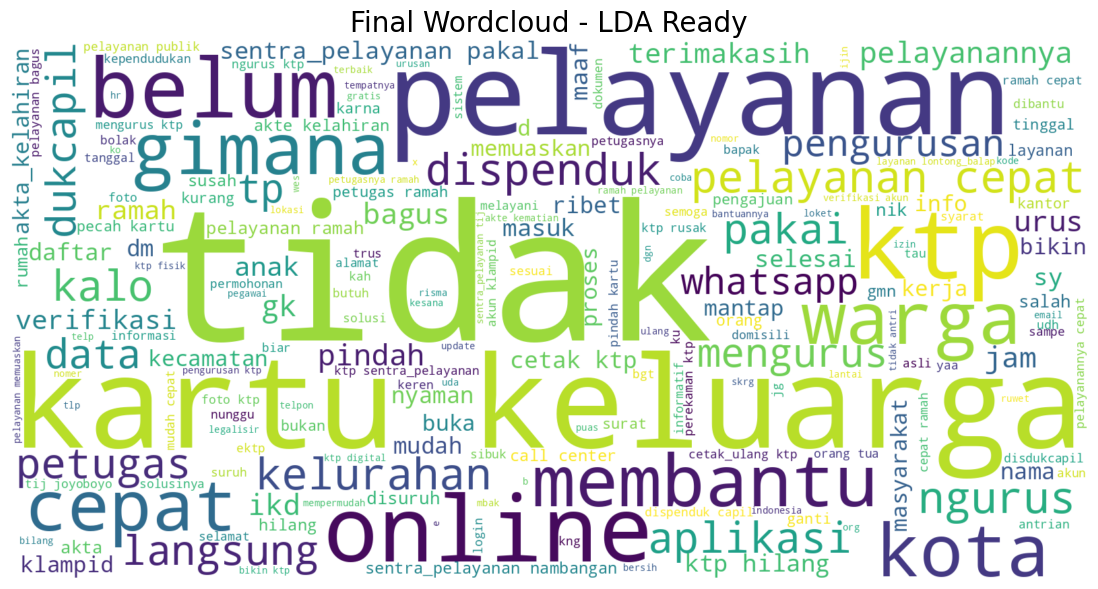

In [27]:
#@title Wordcloud Final
plot_wordcloud(df['text_for_lda'], "Final Wordcloud - LDA Ready")

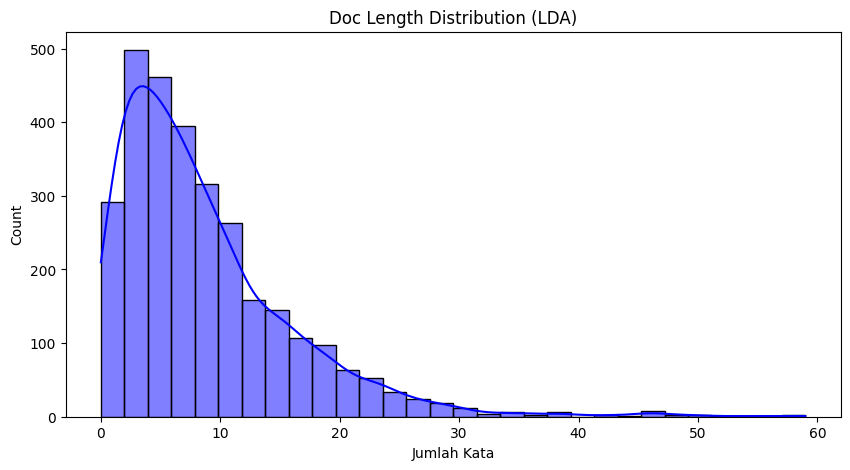

In [28]:
#@title Document Length Distribution
plot_dist(df, 'text_for_lda', "Doc Length Distribution (LDA)", "blue")

/tmp/ipykernel_18176/2564875411.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='source', palette='pastel')


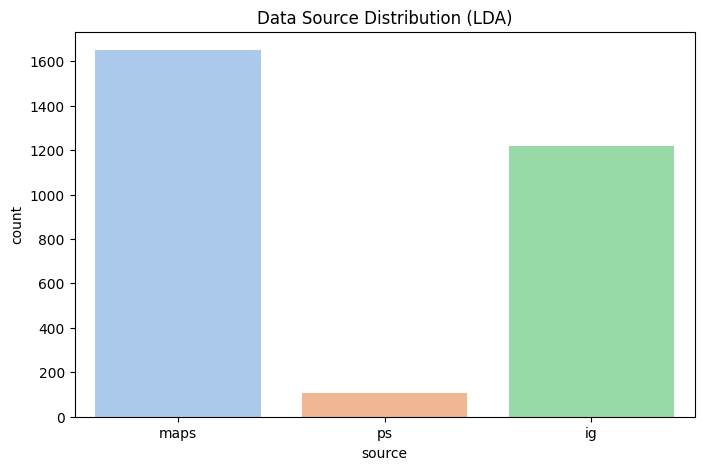

In [29]:
#@title Source Distribution
plot_source(df, "Data Source Distribution (LDA)")

## IndoBERT

/tmp/ipykernel_18176/2564875411.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(values), y=list(labels), palette=color)


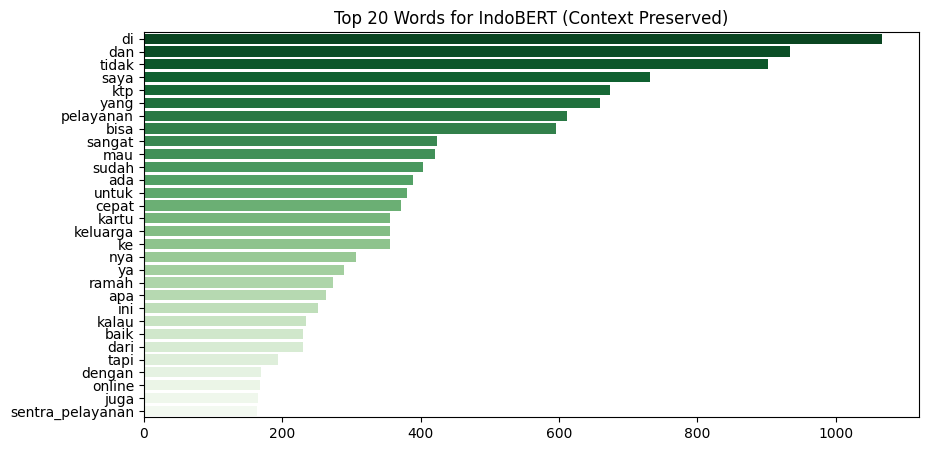

In [ ]:
#@title Perbandingan Freq
plot_freq(df['text_for_bertopic'], "Top 20 Words for IndoBERT (Context Preserved)", "Greens_r")

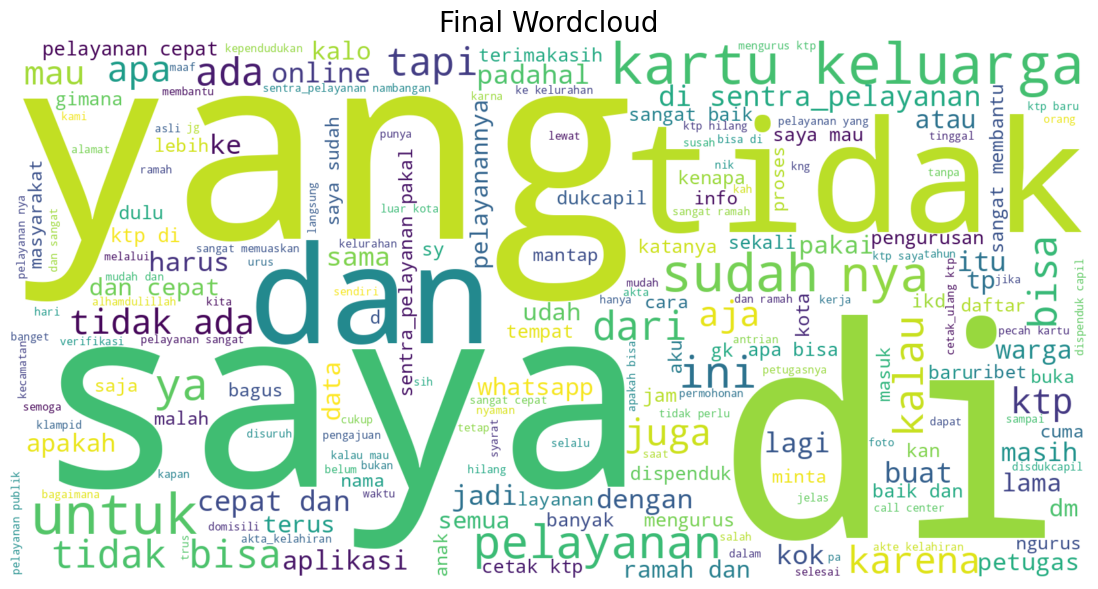

In [31]:
#@title Wordcloud Final
plot_wordcloud(df['text_for_bertopic'], "Final Wordcloud")

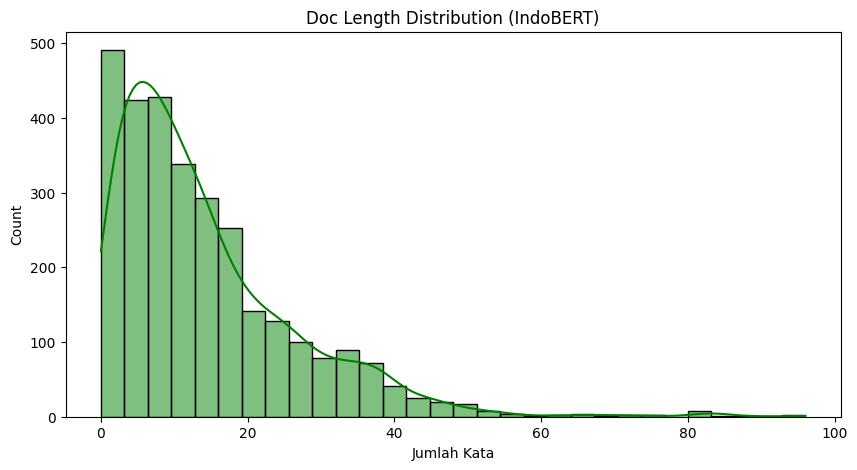

In [ ]:
#@title Document Length Distribution
plot_dist(df, 'text_for_bertopic', "Doc Length Distribution (IndoBERT)", "green")

/tmp/ipykernel_18176/2564875411.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='source', palette='pastel')


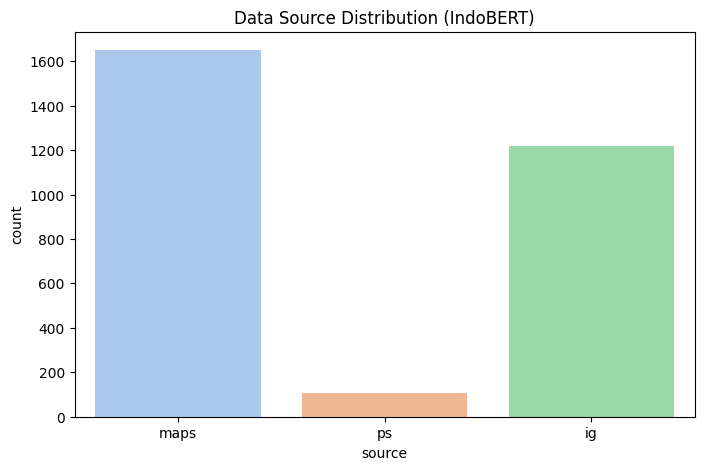

In [33]:
#@title Source Distribution
plot_source(df, "Data Source Distribution (IndoBERT)")

In [34]:
df

,source,comments,timestamp,text_clean,text_refined,text_for_lda,text_for_bertopic
0,maps,Siola Mall Pelayanan Publik Dinas Kependudukan...,NaN,siola mall pelayanan publik dinas kependudukan...,siola mall pelayanan publik dinas kependudukan...,mall pelayanan publik dinas kependudukan catat...,mall pelayanan publik dinas kependudukan dan c...
1,maps,Tempatnya bagus... Pelayanan cepat tapi sayang...,NaN,tempatnya bagus pelayanan cepat tapi sayang pe...,tempatnya bagus pelayanan cepat tapi sayang pe...,tempatnya bagus pelayanan cepat sayang petugas...,tempatnya bagus pelayanan cepat tapi sayang pe...
2,maps,Disdukcapil Surabaya: Inovasi Digital Demi War...,NaN,disdukcapil surabaya inovasi digital demi warg...,disdukcapil surabaya inovasi digital demi warg...,disdukcapil inovasi digital warga kota pahlawa...,disdukcapil inovasi digital demi warga kota pa...
3,maps,pelayanan adminduk di spp nambangan sangat bai...,NaN,pelayanan adminduk di spp nambangan sangat bai...,pelayanan adminduk di sentra_pelayanan nambang...,pelayanan adminduk sentra_pelayanan nambangan ...,pelayanan adminduk di sentra_pelayanan nambang...
4,maps,mengurus KK di Pelayanan Publik Nambangan sang...,NaN,mengurus kk di pelayanan publik nambangan sang...,mengurus kartu keluarga di pelayanan publik na...,mengurus kartu keluarga pelayanan publik namba...,mengurus kartu keluarga di pelayanan publik na...
...,...,...,...,...,...,...,...
2969,ig,"Siola lantai brp ?, kok gak ada petugas",2026-03-09,siola lantai brp kok gak ada petugas,siola lantai brp kok tidak ada petugas,lantai brp tidak petugas,lantai brp kok tidak ada petugas
2970,ig,Saya mau cetak KTP fisik tp GK ada blangko ter...,2026-03-09,saya mau cetak ktp fisik tp gk ada blangko ter...,saya mau cetak ktp fisik tp gk ada blangko ter...,cetak ktp fisik tp gk blangko klok kebutuhan b...,saya mau cetak ktp fisik tp gk ada blangko ter...
2971,ig,untuk pengurusan cetak uLang akta gmn yah ? tl...,2026-03-09,untuk pengurusan cetak ulang akta gmn yah tlp ...,untuk pengurusan cetak_ulang akta gmn yah tlp ...,pengurusan cetak_ulang akta gmn yah tlp yo sib...,untuk pengurusan cetak_ulang akta gmn yah tlp ...
2972,ig,Apakah d perlukan,2026-03-09,apakah d perlukan,apakah d perlukan,d perlukan,apakah d perlukan


In [35]:
import numpy as np

def check_and_clean_empty(df, col_name):
    df['temp_word_count'] = df[col_name].apply(lambda x: len(str(x).split()))
    empty_rows = df[df['temp_word_count'] == 0]
    print(f"=== Analisis Kolom: {col_name} ===")
    print(f"Jumlah baris kosong: {len(empty_rows)}")

    if len(empty_rows) > 0:
        print("Teks asli")
        display(df.loc[empty_rows.index, ['text_refined']].head(5))
    df_clean = df[df['temp_word_count'] > 0].copy()
    df_clean.drop(columns=['temp_word_count'], inplace=True)

    return df_clean

print(f"Jumlah awal: {len(df)}")
df = check_and_clean_empty(df, 'text_for_lda')
df = check_and_clean_empty(df, 'text_for_bertopic')

print(f"\nJumlah data final: {len(df)}")
df.reset_index(drop=True, inplace=True)

Jumlah awal: 2974
=== Analisis Kolom: text_for_lda ===
Jumlah baris kosong: 89
Teks asli


,text_refined
1305,dispendukcapil surabaya memang oke
1307,
1387,baik sekali
1401,
1403,lebih tepat waktu


=== Analisis Kolom: text_for_bertopic ===
Jumlah baris kosong: 0

Jumlah data final: 2885


In [36]:
df.to_csv("data.csv", index=False)